# Group 3 Exploration — Collision Type Flags (13 Yes/No columns)

Columns: PEDESTRIAN, CYCLIST, AUTOMOBILE, MOTORCYCLE, TRUCK, TRSN_CITY_VEH, EMERG_VEH, PASSENGER, SPEEDING, AG_DRIV, REDLIGHT, ALCOHOL, DISABILITY

Each column is `Yes` if that factor applied to the collision, blank otherwise (per the KSI glossary — these are not standard missing values, blank means "No").

In [1]:
import pandas as pd

df = pd.read_csv('../data/TOTAL_KSI_4115794401574937330.csv', encoding='utf-8-sig')
df.shape

(18957, 54)

## Target column cleanup

`ACCLASS` has 4 real values: `Fatal`, `Non-Fatal Injury`, `Property Damage O` (truncated "Property Damage Only"), and blank. Blank rows have no usable label and are dropped. Binary target: 1 = Fatal, 0 = everything else.

In [2]:
df = df[df['ACCLASS'].notna() & (df['ACCLASS'].str.strip() != '')]
df['FATAL'] = df['ACCLASS'].apply(lambda x: 1 if str(x).strip().lower() == 'fatal' else 0)
print('Rows after dropping blank ACCLASS:', len(df))
print('Overall fatal rate: {:.2f}%'.format(df['FATAL'].mean() * 100))

Rows after dropping blank ACCLASS: 18956
Overall fatal rate: 14.09%


## Missing data / prevalence check for each flag

In [3]:
flags = ['PEDESTRIAN','CYCLIST','AUTOMOBILE','MOTORCYCLE','TRUCK',
         'TRSN_CITY_VEH','EMERG_VEH','PASSENGER','SPEEDING','AG_DRIV',
         'REDLIGHT','ALCOHOL','DISABILITY']

rows = []
for f in flags:
    is_yes = df[f].astype(str).str.strip().str.lower() == 'yes'
    pct_yes = is_yes.mean() * 100
    fatal_if_yes = df.loc[is_yes, 'FATAL'].mean() * 100
    fatal_if_no = df.loc[~is_yes, 'FATAL'].mean() * 100
    rows.append((f, is_yes.sum(), pct_yes, fatal_if_yes, fatal_if_no))

stats = pd.DataFrame(rows, columns=['flag','yes_count','pct_yes','fatal_rate_if_yes','fatal_rate_if_no'])
stats = stats.sort_values('fatal_rate_if_yes', ascending=False)
stats

,flag,yes_count,pct_yes,fatal_rate_if_yes,fatal_rate_if_no
4,TRUCK,1169,6.166913,29.170231,13.093833
8,SPEEDING,2693,14.206584,21.797252,12.808215
5,TRSN_CITY_VEH,1148,6.056130,20.557491,13.668014
11,ALCOHOL,808,4.262503,18.811881,13.874807
0,PEDESTRIAN,7688,40.557080,18.262227,11.235357
7,PASSENGER,7183,37.893015,13.907838,14.193494
3,MOTORCYCLE,1684,8.883731,13.479810,14.144280
10,REDLIGHT,1577,8.319266,13.379835,14.149261
2,AUTOMOBILE,17229,90.889428,13.262522,22.292994
9,AG_DRIV,9835,51.883309,12.984240,15.272448


## Findings

Real numbers from the current dataset (18,956 labeled rows, overall fatal rate 14.09%):

| Flag | % of records | Fatal rate if Yes | Fatal rate if No |
|---|---|---|---|
| TRUCK | 6.17% | **29.17%** | 13.09% |
| SPEEDING | 14.21% | **21.80%** | 12.81% |
| TRSN_CITY_VEH | 6.06% | 20.56% | 13.67% |
| ALCOHOL | 4.26% | 18.81% | 13.87% |
| PEDESTRIAN | 40.56% | 18.26% | 11.24% |
| PASSENGER | 37.89% | 13.91% | 14.19% |
| MOTORCYCLE | 8.88% | 13.48% | 14.14% |
| REDLIGHT | 8.32% | 13.38% | 14.15% |
| AUTOMOBILE | 90.89% | 13.26% | 22.29% |
| AG_DRIV | 51.88% | 12.98% | 15.27% |
| DISABILITY | 2.60% | 12.60% | 14.12% |
| CYCLIST | 10.48% | 6.45% | 14.98% |
| EMERG_VEH | 0.26% | 4.08% | 14.11% |

**Strongest apparent risk factors:** collisions involving a truck, speeding, transit/city vehicles, or alcohol have a noticeably higher fatal rate than the 14.09% baseline (truck almost doubles it). Pedestrian involvement also raises the fatal rate.

**Weakest / possibly protective in this raw view:** cyclist and emergency-vehicle involvement show a *lower* fatal rate than baseline — likely because these collisions tend to happen at lower speeds or involve people already exercising more caution, not because cycling is inherently safer. Needs more digging before assuming causation.

**Caveat:** AUTOMOBILE is Yes for 91% of rows, so its "fatal rate if No" (22.29%) is based on a small, possibly unusual subset (motorcycle-only, pedestrian-only collisions, etc.) — treat that number cautiously.

These are single-variable comparisons, not controlling for other factors — real correlation/feature-importance analysis comes during modelling (Group 4).

## Visualization

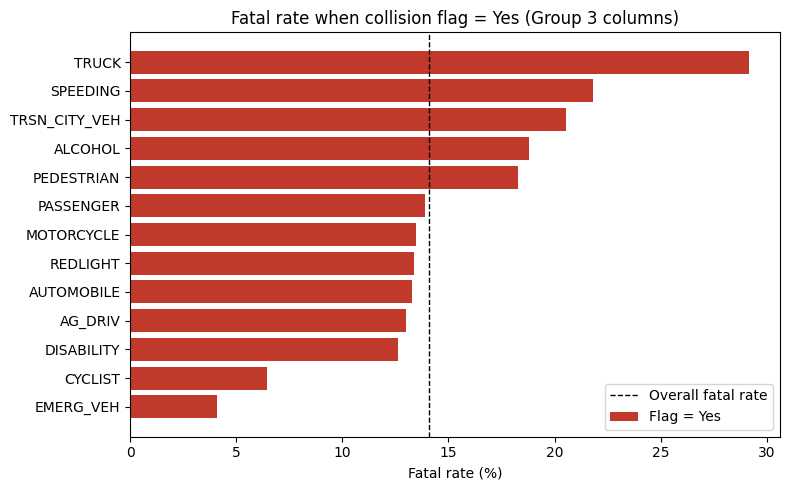

In [4]:
import matplotlib.pyplot as plt

plot_stats = stats.sort_values('fatal_rate_if_yes', ascending=True)
fig, ax = plt.subplots(figsize=(8,5))
ax.barh(plot_stats['flag'], plot_stats['fatal_rate_if_yes'], color='#c0392b', label='Flag = Yes')
ax.axvline(df['FATAL'].mean()*100, color='black', linestyle='--', linewidth=1, label='Overall fatal rate')
ax.set_xlabel('Fatal rate (%)')
ax.set_title('Fatal rate when collision flag = Yes (Group 3 columns)')
ax.legend()
plt.tight_layout()
plt.show()

## Follow-up: are SPEEDING and AG_DRIV independent signals?

Added during Part 2 report review, in response to feedback on Part 1 asking for
deeper interpretation of relationships and clearer evidence for feature
decisions. Checks whether SPEEDING and AG_DRIV (both Group 3 flags) are giving
independent information, or overlapping information.

In [5]:
def is_yes(s):
    return s.astype(str).str.strip().str.lower() == 'yes'

speeding = is_yes(df['SPEEDING'])
agdriv = is_yes(df['AG_DRIV'])

combo_rows = []
for s_val, s_label in [(True, 'Speeding=Yes'), (False, 'Speeding=No')]:
    for a_val, a_label in [(True, 'AG_DRIV=Yes'), (False, 'AG_DRIV=No')]:
        mask = (speeding == s_val) & (agdriv == a_val)
        n = mask.sum()
        rate = df.loc[mask, 'FATAL'].mean() * 100 if n > 0 else float('nan')
        combo_rows.append((s_label, a_label, n, rate))

combo = pd.DataFrame(combo_rows, columns=['speeding', 'ag_driv', 'n', 'fatal_rate_pct'])
print(combo.to_string(index=False))
print()
pct_overlap_when_speeding = agdriv[speeding].mean() * 100
pct_overlap_when_not = agdriv[~speeding].mean() * 100
print(f"% of SPEEDING=Yes records that are also AG_DRIV=Yes: {pct_overlap_when_speeding:.1f}%")
print(f"% of SPEEDING=No records that are also AG_DRIV=Yes: {pct_overlap_when_not:.1f}%")

    speeding     ag_driv    n  fatal_rate_pct
Speeding=Yes AG_DRIV=Yes 2693       21.797252
Speeding=Yes  AG_DRIV=No    0             NaN
 Speeding=No AG_DRIV=Yes 7142        9.661159
 Speeding=No  AG_DRIV=No 9121       15.272448

% of SPEEDING=Yes records that are also AG_DRIV=Yes: 100.0%
% of SPEEDING=No records that are also AG_DRIV=Yes: 43.9%


**Finding:** every single SPEEDING=Yes record is also AG_DRIV=Yes (100% overlap) —
SPEEDING behaves as a subset of AG_DRIV in this dataset, not an independent
risk factor. Splitting AG_DRIV's own fatal rate (12.98% overall) by whether
SPEEDING also applies shows the speeding subset at 21.80% fatal vs. only 9.66%
for aggressive-driving collisions that are *not* also flagged as speeding —
below the 14.09% baseline. AG_DRIV's elevated rate is being driven almost
entirely by its speeding subset. Kept both columns anyway (see Feature
Selection in the report) since one-hot encoding tolerates correlated
categorical inputs without the issues correlated features cause for methods
like linear regression.

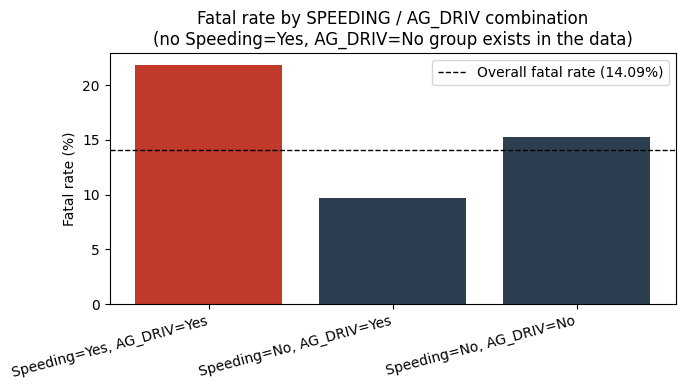

In [6]:
import matplotlib.pyplot as plt

combo_plot = combo.dropna(subset=['fatal_rate_pct']).copy()
combo_plot['label'] = combo_plot['speeding'] + ', ' + combo_plot['ag_driv']

fig, ax = plt.subplots(figsize=(7, 4))
colors = ['#c0392b' if 'Speeding=Yes' in l else '#2c3e50' for l in combo_plot['label']]
ax.bar(combo_plot['label'], combo_plot['fatal_rate_pct'], color=colors)
ax.axhline(df['FATAL'].mean() * 100, color='black', linestyle='--', linewidth=1, label='Overall fatal rate (14.09%)')
ax.set_ylabel('Fatal rate (%)')
ax.set_title('Fatal rate by SPEEDING / AG_DRIV combination\n(no Speeding=Yes, AG_DRIV=No group exists in the data)')
ax.legend()
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.savefig('/sessions/eager-awesome-newton/mnt/outputs/charts/group3_speeding_agdriv_overlap.png', dpi=150)
plt.show()

## Follow-up: does the RDSFCOND paradox come from more speeding on dry roads?

Group 1's exploration found dry roads have a *higher* fatal rate (14.0%) than
wet, snow, or ice — the working theory was that drivers feel safer and speed
more on dry roads. Testing that directly against SPEEDING by road surface.

In [7]:
rds = df['RDSFCOND'].astype(str).str.strip()
conditions = ['Dry', 'Wet', 'Loose Snow', 'Ice']

rds_rows = []
for cond in conditions:
    mask = rds == cond
    n = mask.sum()
    if n > 0:
        speed_rate = speeding[mask].mean() * 100
        rds_rows.append((cond, n, speed_rate))

rds_stats = pd.DataFrame(rds_rows, columns=['road_condition', 'n', 'speeding_rate_pct'])
print(rds_stats.to_string(index=False))

road_condition     n  speeding_rate_pct
           Dry 15230          14.103743
           Wet  3140          12.707006
    Loose Snow   174          25.862069
           Ice    78          53.846154


**Finding: the hypothesis was wrong.** Speeding is reported far *more* often
on Ice (53.85% of records) and Loose Snow (25.86%) than on Dry (14.10%) or Wet
(12.71%) roads — the opposite of "drivers speed more when roads feel safe."
Since the fatal rate is still lower on ice and snow despite speeding being
more frequent there, the more likely explanation is that SPEEDING captures a
*relative*, condition-adjusted judgment rather than absolute speed —
"speeding" on ice still means driving slower in real terms than an unflagged
dry-road driver. Worth documenting as a genuine test of a hypothesis that
turned out to be wrong, rather than dropping it silently — this is the kind
of "deeper interpretation" the Part 1 feedback asked for.

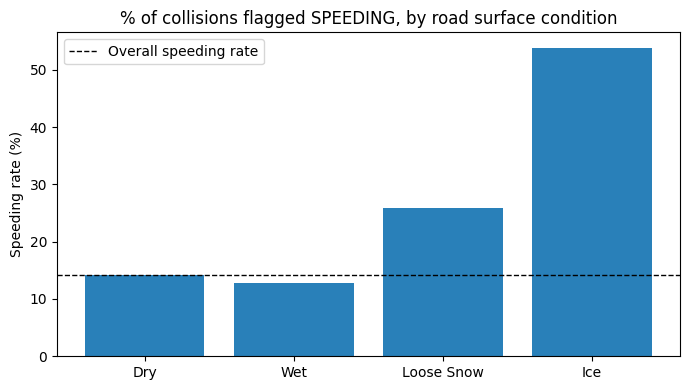

In [8]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(rds_stats['road_condition'], rds_stats['speeding_rate_pct'], color='#2980b9')
ax.axhline(speeding.mean() * 100, color='black', linestyle='--', linewidth=1, label='Overall speeding rate')
ax.set_ylabel('Speeding rate (%)')
ax.set_title('% of collisions flagged SPEEDING, by road surface condition')
ax.legend()
plt.tight_layout()
plt.savefig('/sessions/eager-awesome-newton/mnt/outputs/charts/group1_speeding_rate_by_rdsfcond.png', dpi=150)
plt.show()